# 04 — Backtesting e Sizing Dinâmico
**BOVA11 ML Pipeline**

Objetivo: avaliar a estratégia do modelo em termos de retorno acumulado, Sharpe ratio e drawdown, comparado ao buy & hold.

---

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [21]:
df           = pd.read_parquet('../data/processed/bova11_features.parquet')
model        = joblib.load('../models/lightgbm_final.pkl')
feature_cols = joblib.load('../models/feature_cols.pkl')

n = len(df)
i_test = int(n * 0.85)
df_test = df.iloc[i_test:].copy()

print(f'Período de backtest: {df_test.index[0].date()} → {df_test.index[-1].date()}')
print(f'Dias de trading: {len(df_test)}')

Período de backtest: 2023-08-22 → 2024-12-30
Dias de trading: 339


## 1. Gerar predições no conjunto de teste

In [22]:
X_test = df_test[feature_cols]

df_test['prob_alta'] = model.predict_proba(X_test)[:, 1]
df_test['sinal']     = np.where(df_test['prob_alta'] > 0.535, 1, -1)  # long/short

# Retorno do dia seguinte (já disponível no test set)
# sinal de hoje → retorno amanhã (shift já foi feito no target)
df_test['ret_modelo'] = df_test['sinal'] * df_test['retorno'].shift(-1)
df_test = df_test.dropna(subset=['ret_modelo'])

print(f'Sinal +1 (long): {(df_test["sinal"]==1).mean():.2%} dos dias')
print(f'Sinal -1 (short): {(df_test["sinal"]==-1).mean():.2%} dos dias')

Sinal +1 (long): 58.28% dos dias
Sinal -1 (short): 41.72% dos dias


## 2. Sizing dinâmico por Sharpe rolling

In [23]:
janela_sharpe = 60

def sharpe_rolling(retornos, janela):
    media = retornos.rolling(janela).mean()
    std   = retornos.rolling(janela).std()
    return (media / std) * np.sqrt(252)

df_test['sharpe_rolling'] = sharpe_rolling(df_test['ret_modelo'], janela_sharpe)

# Normaliza entre 0 e 1 — sizing proporcional ao Sharpe
sharpe_max = df_test['sharpe_rolling'].quantile(0.95)
df_test['sizing'] = (df_test['sharpe_rolling'] / sharpe_max).clip(0, 1).fillna(0.5)

# Retorno com sizing dinâmico
df_test['ret_sizing'] = df_test['sizing'].shift(1) * df_test['ret_modelo']

print('Sizing calculado. Média de exposição:', df_test['sizing'].mean().round(3))

Sizing calculado. Média de exposição: 0.424


## 3. Performance acumulada

In [24]:
df_test['cum_modelo']   = (1 + df_test['ret_modelo']).cumprod()
df_test['cum_sizing']   = (1 + df_test['ret_sizing'].fillna(0)).cumprod()
df_test['cum_bnh']      = (1 + df_test['retorno']).cumprod()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_test.index, y=df_test['cum_sizing'],
                         name='Modelo (sizing dinâmico)',
                         line=dict(color='#2563eb', width=2.5)))
fig.add_trace(go.Scatter(x=df_test.index, y=df_test['cum_modelo'],
                         name='Modelo (peso fixo)',
                         line=dict(color='#22c55e', width=1.5, dash='dot')))
fig.add_trace(go.Scatter(x=df_test.index, y=df_test['cum_bnh'],
                         name='Buy & Hold',
                         line=dict(color='#94a3b8', width=1.5, dash='dash')))

fig.update_layout(title='Retorno acumulado — Modelo vs Buy & Hold',
                  yaxis_title='Retorno acumulado (base 1.0)',
                  template='plotly_white', height=420)
fig.show()

## 4. Métricas de performance

In [25]:
def metricas(retornos, nome):
    ret = retornos.dropna()
    sharpe    = (ret.mean() / ret.std()) * np.sqrt(252)
    retorno_a = (1 + ret).prod() ** (252 / len(ret)) - 1
    cum       = (1 + ret).cumprod()
    drawdown  = (cum / cum.cummax() - 1).min()
    win_rate  = (ret > 0).mean()
    return {'Estratégia': nome,
            'Retorno Anual': f'{retorno_a:.2%}',
            'Sharpe':        f'{sharpe:.3f}',
            'Max Drawdown':  f'{drawdown:.2%}',
            'Win Rate':      f'{win_rate:.2%}'}

resultados = pd.DataFrame([
    metricas(df_test['retorno'],     'Buy & Hold'),
    metricas(df_test['ret_modelo'],  'Modelo (peso fixo)'),
    metricas(df_test['ret_sizing'],  'Modelo (sizing dinâmico)'),
])

print('=== Performance Summary ===')
print(resultados.to_string(index=False))

resultados.to_csv('../data/processed/performance_summary.csv', index=False)

=== Performance Summary ===
              Estratégia Retorno Anual Sharpe Max Drawdown Win Rate
              Buy & Hold         4.32%  0.368      -12.24%   50.30%
      Modelo (peso fixo)        22.66%  1.515       -7.64%   52.07%
Modelo (sizing dinâmico)        10.44%  1.287       -4.18%   44.51%


## 5. Drawdown ao longo do tempo

In [26]:
def calc_drawdown(cum):
    return cum / cum.cummax() - 1

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    row_heights=[0.65, 0.35],
                    subplot_titles=['Retorno acumulado', 'Drawdown'])

for nome, col, cor in [('Modelo sizing', 'cum_sizing', '#2563eb'),
                        ('Buy & Hold',   'cum_bnh',    '#94a3b8')]:
    fig.add_trace(go.Scatter(x=df_test.index, y=df_test[col],
                             name=nome, line=dict(color=cor)), row=1, col=1)
    dd = calc_drawdown(df_test[col])
    fig.add_trace(go.Scatter(x=df_test.index, y=dd * 100,
                             name=f'DD {nome}', showlegend=False,
                             fill='tozeroy',
                             fillcolor='rgba(37,99,235,0.12)' if 'sizing' in nome else 'rgba(148,163,184,0.12)',
                             line=dict(color=cor, width=1)), row=2, col=1)

fig.update_layout(height=550, template='plotly_white',
                  title='Backtest out-of-sample — BOVA11 ML Pipeline')
fig.update_yaxes(title_text='Drawdown (%)', row=2, col=1)
fig.show()

## 6. Distribuição mensal dos retornos

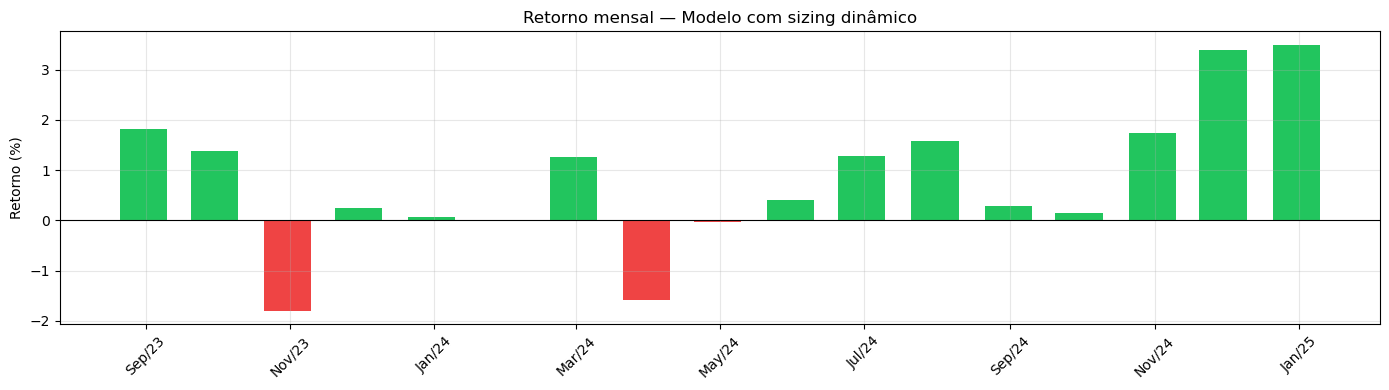


✅ Pipeline completo!
Todos os resultados salvos em /data/processed/


In [27]:
ret_mensal = df_test['ret_sizing'].resample('ME').sum()
cores = ['#22c55e' if v >= 0 else '#ef4444' for v in ret_mensal]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(ret_mensal.index, ret_mensal * 100, color=cores, width=20)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Retorno mensal — Modelo com sizing dinâmico')
ax.set_ylabel('Retorno (%)')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/retorno_mensal.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Pipeline completo!')
print('Todos os resultados salvos em /data/processed/')